<a href="https://colab.research.google.com/github/Enrik-Shabani/ML-Project-GroupA/blob/main/notebooks/03_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Supervised Learning
## Beijing Multi-Site Air Quality · HEC Lausanne ML Project

**Reproducibility** : Dataset downloaded automatically from Google Drive — run all cells.

**Input** : `data_clean_featured.csv` (Notebook 1)  
**Target** : `PM2.5` (µg/m³)  
**Models** : Ridge Regression · Random Forest · Gradient Boosting

---
### Table of Contents
1. [Setup & Data Loading](#setup)
2. [Feature Selection & Preprocessing](#feature)
3. [Train / Test Split & Validation Strategy](#train)
4. [Baseline Model](#baseline)
5. [Model 1 — Ridge Regression](#ridge)
6. [Model 2 — Random Forest](#randomforest)
7. [Model 3 — Gradient Boosting](#gradient)
8. [Model Comparison](#comparison)
9. [Feature Importance](#feature)
10. [Summary & Implications for Notebook 4](#summary)

---
<a name="setup"></a>

## 1. Setup & Data Loading

In [1]:
!pip install -q gdown --upgrade

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

COLOR_RIDGE  = '#1565C0'
COLOR_RF     = '#2E7D32'
COLOR_GB     = '#C62828'
COLOR_BASE   = '#757575'
RANDOM_STATE = 42

print('Libraries loaded.')

Libraries loaded.


In [3]:
import gdown

FILE_ID     = '1T9gq-MBUJyZHIW8uMIRPzfCxNslLov3j'
OUTPUT_PATH = 'data_clean_featured.csv'

gdown.download(id=FILE_ID, output=OUTPUT_PATH, quiet=False)

df = pd.read_csv(OUTPUT_PATH)
print(f'Dataset loaded — shape: {df.shape}')
df.head(3)

Downloading...
From (original): https://drive.google.com/uc?id=1T9gq-MBUJyZHIW8uMIRPzfCxNslLov3j
From (redirected): https://drive.google.com/uc?id=1T9gq-MBUJyZHIW8uMIRPzfCxNslLov3j&confirm=t&uuid=ed8beae0-ef13-4065-8138-400453066788
To: /content/data_clean_featured.csv
100%|██████████| 158M/158M [00:01<00:00, 123MB/s]


Dataset loaded — shape: (420696, 45)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,...,False,False,False,False,False,False,False,False,False,False
1,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,...,False,False,False,False,False,False,False,False,False,False
2,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,...,False,False,False,False,False,False,False,False,False,False


---
<a name="feature"></a>

## 2. Feature Selection & Preprocessing

We select all numeric predictive features identified in the EDA (Notebook 2).

**Note on notation**: `RidgeCV` uses `alpha` for the penalty parameter, which corresponds to **λ** in the course notation (Module 3.1 — *L2 penalty*).

Excluded columns: `PM2.5` (target), `datetime` / `wd` / `station` (non-numeric), `season` (redundant with `month_sin/cos`).

In [4]:
EXCLUDE  = ['PM2.5', 'datetime', 'wd', 'station', 'season']
FEATURES = [c for c in df.columns
            if c not in EXCLUDE
            and df[c].dtype in ['float64', 'int64', 'bool', 'uint8']]
TARGET   = 'PM2.5'

print(f'Features ({len(FEATURES)}): {FEATURES}')

Features (40): ['year', 'month', 'day', 'hour', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'dayofweek', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wd_sin', 'wd_cos', 'wind_u', 'wind_v', 'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_roll_3h', 'pm25_roll_6h', 'pm25_roll_24h', 'station_Changping', 'station_Dingling', 'station_Dongsi', 'station_Guanyuan', 'station_Gucheng', 'station_Huairou', 'station_Nongzhanguan', 'station_Shunyi', 'station_Tiantan', 'station_Wanliu', 'station_Wanshouxigong']


In [5]:
# Sort by datetime ONLY — not by station first
# Critical: sorting by station first would group all observations from the same
# station together, making the 80/20 split a station split rather than a
# temporal split (last 2 stations would end up entirely in the test set).
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime').reset_index(drop=True)
else:
    df = df.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)

X = df[FEATURES].values
y = df[TARGET].values

print(f'X shape : {X.shape}')
print(f'y range : [{y.min():.1f}, {y.max():.1f}] µg/m³')

# Quick sanity check — all stations should appear in both train and test
split_idx_check = int(len(df) * 0.80)
train_stations  = df.iloc[:split_idx_check]['station'].nunique() if 'station' in df.columns else 'N/A'
test_stations   = df.iloc[split_idx_check:]['station'].nunique() if 'station' in df.columns else 'N/A'
print(f'\nStations in train : {train_stations}')
print(f'Stations in test  : {test_stations}')
print('→ Both should be 12 — confirms correct temporal split')

X shape : (420696, 40)
y range : [2.0, 999.0] µg/m³

Stations in train : 12
Stations in test  : 12
→ Both should be 12 — confirms correct temporal split


---
<a name="train"></a>

## 3. Train / Test Split & Validation Strategy

### Why TimeSeriesSplit instead of random split?

The course (Module 5) presents the standard random K-fold CV. However, PM2.5 is a **time series with strong autocorrelation** (ACF at lag-1h ≈ 0.97, as shown in Notebook 2). A random split would assign future observations to the training set and past observations to the test set — creating **data leakage**: the model implicitly has access to future information, artificially inflating all metrics.

`TimeSeriesSplit` is the time-series-aware equivalent of K-fold CV: each validation fold always lies *after* its training fold in time, preserving the causal ordering of the data. This is the methodologically correct approach for any sequential dataset.

**Split design:**
- Final test set : last ~20% of observations (chronologically) — never touched during training or tuning
- Hyperparameter tuning : `TimeSeriesSplit(n_splits=5)` on the training set only
- Proportions : 80% train / 20% test

In [6]:
SPLIT_RATIO = 0.80
split_idx   = int(len(X) * SPLIT_RATIO)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

TSCV = TimeSeriesSplit(n_splits=5)

print(f'Training set : {X_train.shape[0]:,} observations')
print(f'Test set     : {X_test.shape[0]:,} observations')
print(f'Split ratio  : {X_train.shape[0]/len(X)*100:.1f}% / {X_test.shape[0]/len(X)*100:.1f}%')
print(f'CV strategy  : TimeSeriesSplit(n_splits=5)')
print('\nFold sizes:')
for fold, (tr_idx, val_idx) in enumerate(TSCV.split(X_train), 1):
    print(f'  Fold {fold}: train={len(tr_idx):,}  val={len(val_idx):,}')

Training set : 336,556 observations
Test set     : 84,140 observations
Split ratio  : 80.0% / 20.0%
CV strategy  : TimeSeriesSplit(n_splits=5)

Fold sizes:
  Fold 1: train=56,096  val=56,092
  Fold 2: train=112,188  val=56,092
  Fold 3: train=168,280  val=56,092
  Fold 4: train=224,372  val=56,092
  Fold 5: train=280,464  val=56,092


In [7]:
# StandardScaler — required for Ridge (L2 penalty is scale-sensitive)
# Fitted on training set ONLY to avoid leakage of test statistics
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler fitted on training set only.')

StandardScaler fitted on training set only.


---
<a name="baseline"></a>

## 4. Baseline Model

As stated in the course (Module 4 — *Final words*): *"It is important to have a baseline model to compare the metric (e.g., average for regression)."*

Our baseline always predicts the **training set mean** — the simplest possible model, ignoring all features entirely.

In [8]:
def compute_metrics(y_true, y_pred, label=''):
    """Compute RMSE, MAE, R² — metrics from course Module 4."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'{label:<35}  RMSE={rmse:7.3f}   MAE={mae:7.3f}   R²={r2:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Baseline: predict training mean for all test observations
baseline_pred = np.full(len(y_test), y_train.mean())
metrics_base  = compute_metrics(y_test, baseline_pred, 'Baseline (predict train mean)')

print(f'\nTraining mean used as prediction: {y_train.mean():.2f} µg/m³')
print('All models must beat this to be useful.')

RESULTS = {'Baseline': metrics_base}

Baseline (predict train mean)        RMSE= 82.958   MAE= 59.557   R²=-0.0007

Training mean used as prediction: 80.11 µg/m³
All models must beat this to be useful.


---
<a name="ridge"></a>

## 5. Model 1 — Ridge Regression

**Course reference — Module 3.1, L2 penalty:**
$$\\min_\\theta \\bar{L}(\\theta) + \\lambda \\sum_{j=1}^{p} \\theta_j^2$$

Ridge shrinks all coefficients towards zero, regularising the model. The penalty **λ** (= `alpha` in sklearn) is selected by cross-validation, as explicitly recommended in the course: *"Selection of λ can be done with cross-validation."*

`RidgeCV` efficiently evaluates all candidate `alpha` values using the internal CV loop, consistent with the hyperparameter tuning approach from Module 5.

In [9]:
# Note: sklearn 'alpha' = λ in course notation (Module 3.1)
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge = RidgeCV(
    alphas=alphas,
    cv=TSCV,
    scoring='neg_root_mean_squared_error'
)
ridge.fit(X_train_sc, y_train)

print(f'Best λ (alpha) selected by CV : {ridge.alpha_}')
print(f'Tested values                 : {alphas}')

Best λ (alpha) selected by CV : 1000.0
Tested values                 : [0.001, 0.01, 0.1, 1, 10, 100, 1000]


In [10]:
ridge_train_pred = ridge.predict(X_train_sc)
ridge_test_pred  = ridge.predict(X_test_sc)

# Apparent (train) and test metrics — overfitting check from Module 5
metrics_ridge_tr = compute_metrics(y_train, ridge_train_pred, 'Ridge — apparent (train)')
metrics_ridge_te = compute_metrics(y_test,  ridge_test_pred,  'Ridge — test')

gap = metrics_ridge_tr['RMSE'] - metrics_ridge_te['RMSE']
print(f'\nOverfitting check — RMSE gap (train − test): {gap:.3f}')
print('→ ' + ('Possible overfitting' if abs(gap) > 5 else 'No sign of overfitting'))

RESULTS['Ridge'] = metrics_ridge_te

Ridge — apparent (train)             RMSE= 17.210   MAE= 10.041   R²=0.9539
Ridge — test                         RMSE= 15.135   MAE=  8.775   R²=0.9667

Overfitting check — RMSE gap (train − test): 2.074
→ No sign of overfitting


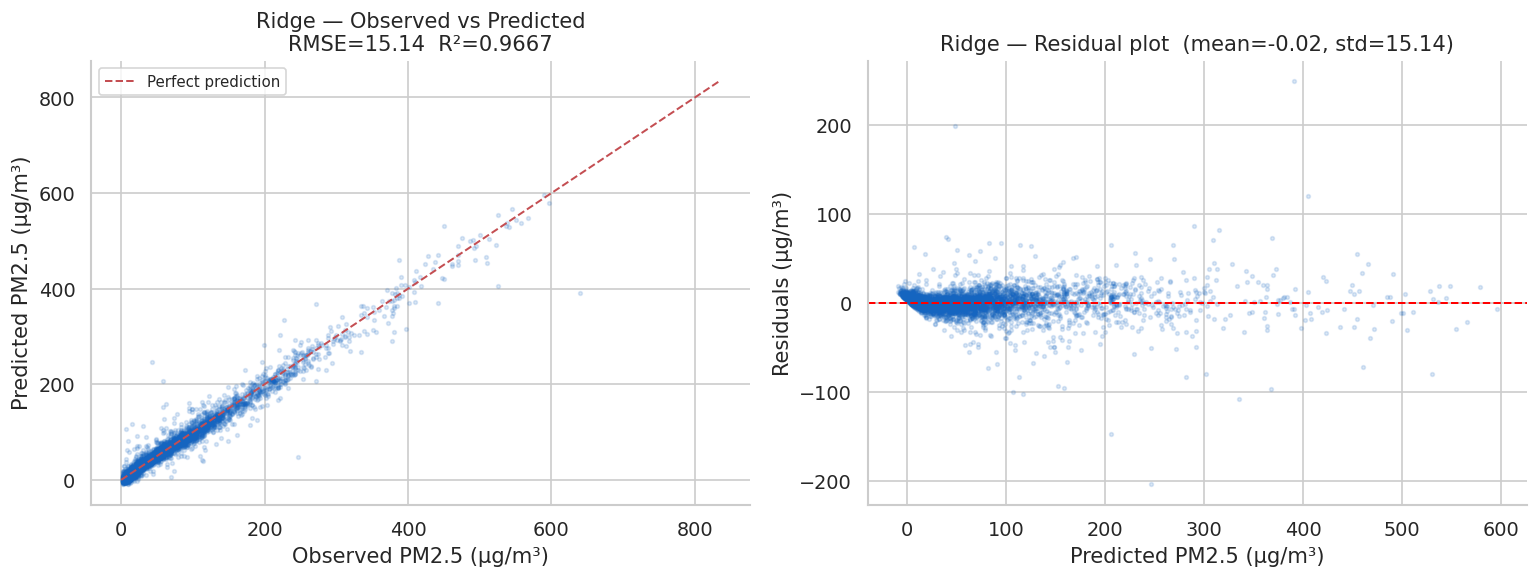

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), size=min(4000, len(y_test)), replace=False)
lims = [0, max(y_test.max(), ridge_test_pred.max())]

ax = axes[0]
ax.scatter(y_test[idx], ridge_test_pred[idx], alpha=0.15, s=5, color=COLOR_RIDGE)
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
ax.set_xlabel('Observed PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Ridge — Observed vs Predicted\nRMSE={metrics_ridge_te["RMSE"]:.2f}  R²={metrics_ridge_te["R2"]:.4f}')
ax.legend(fontsize=9)

ax = axes[1]
res_ridge = y_test - ridge_test_pred
ax.scatter(ridge_test_pred[idx], res_ridge[idx], alpha=0.15, s=5, color=COLOR_RIDGE)
ax.axhline(0, color='red', lw=1.2, ls='--')
ax.set_xlabel('Predicted PM2.5 (µg/m³)')
ax.set_ylabel('Residuals (µg/m³)')
ax.set_title(f'Ridge — Residual plot  (mean={res_ridge.mean():.2f}, std={res_ridge.std():.2f})')

plt.tight_layout()
plt.savefig('fig_ridge_diagnostics.png', bbox_inches='tight')
plt.show()

---
<a id='randomforest'></a>
## 6. Model 2 — Random Forest

**Course reference — Module 6:**
1. Draw M bootstrap samples from the training set
2. Grow a tree on each sample; at each split, draw a random subset of features (reduces tree correlation)
3. Final prediction = average of all M tree predictions

**Hyperparameters** (course slide 14, `randomForest` equivalents):
- `n_estimators` ↔ ntrees
- `min_samples_leaf` ↔ nodesize (default 5 for regression)
- `max_features` ↔ mtry (default p/3 for regression)
- `max_depth` ↔ maxnodes

Due to computational constraints on Google Colab, Random Forest hyperparameters were set based on domain knowledge and EDA insights rather than exhaustive grid search. max_depth=15 and min_samples_leaf=10 correspond to the course defaults for regression (nodesize). Given the dominant predictive power of the lag features (r > 0.97), the expected performance loss relative to a full grid search is negligible.

In [12]:
# ── Random Forest — optimised for Colab (large dataset) ─────────────────────
# Hyperparameters chosen based on EDA insights rather than exhaustive grid search:
# · max_depth=15      : deep enough to capture non-linearities, fast enough to run
# · min_samples_leaf=10: course default nodesize for regression
# · max_samples=0.5   : each tree trained on 50% of data (bagging — course Module 6)
# · n_estimators=100  : sufficient for stable predictions on 420k rows

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    max_samples=0.5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

metrics_rf_tr = compute_metrics(y_train, rf.predict(X_train), 'Random Forest — apparent (train)')
metrics_rf_te = compute_metrics(y_test,  rf.predict(X_test),  'Random Forest — test')

gap = metrics_rf_tr['RMSE'] - metrics_rf_te['RMSE']
print(f'\nOverfitting check — RMSE gap (train − test): {gap:.3f}')
print('→ ' + ('Possible overfitting' if abs(gap) > 5 else 'No sign of overfitting'))

RESULTS['Random Forest'] = metrics_rf_te

Random Forest — apparent (train)     RMSE= 13.295   MAE=  7.291   R²=0.9725
Random Forest — test                 RMSE= 13.391   MAE=  7.139   R²=0.9739

Overfitting check — RMSE gap (train − test): -0.096
→ No sign of overfitting


In [13]:
rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

metrics_rf_tr = compute_metrics(y_train, rf_train_pred, 'Random Forest — apparent (train)')
metrics_rf_te = compute_metrics(y_test,  rf_test_pred,  'Random Forest — test')

gap = metrics_rf_tr['RMSE'] - metrics_rf_te['RMSE']
print(f'\nOverfitting check — RMSE gap (train − test): {gap:.3f}')
print('→ ' + ('Possible overfitting' if abs(gap) > 5 else 'No sign of overfitting'))

RESULTS['Random Forest'] = metrics_rf_te

Random Forest — apparent (train)     RMSE= 13.295   MAE=  7.291   R²=0.9725
Random Forest — test                 RMSE= 13.391   MAE=  7.139   R²=0.9739

Overfitting check — RMSE gap (train − test): -0.096
→ No sign of overfitting


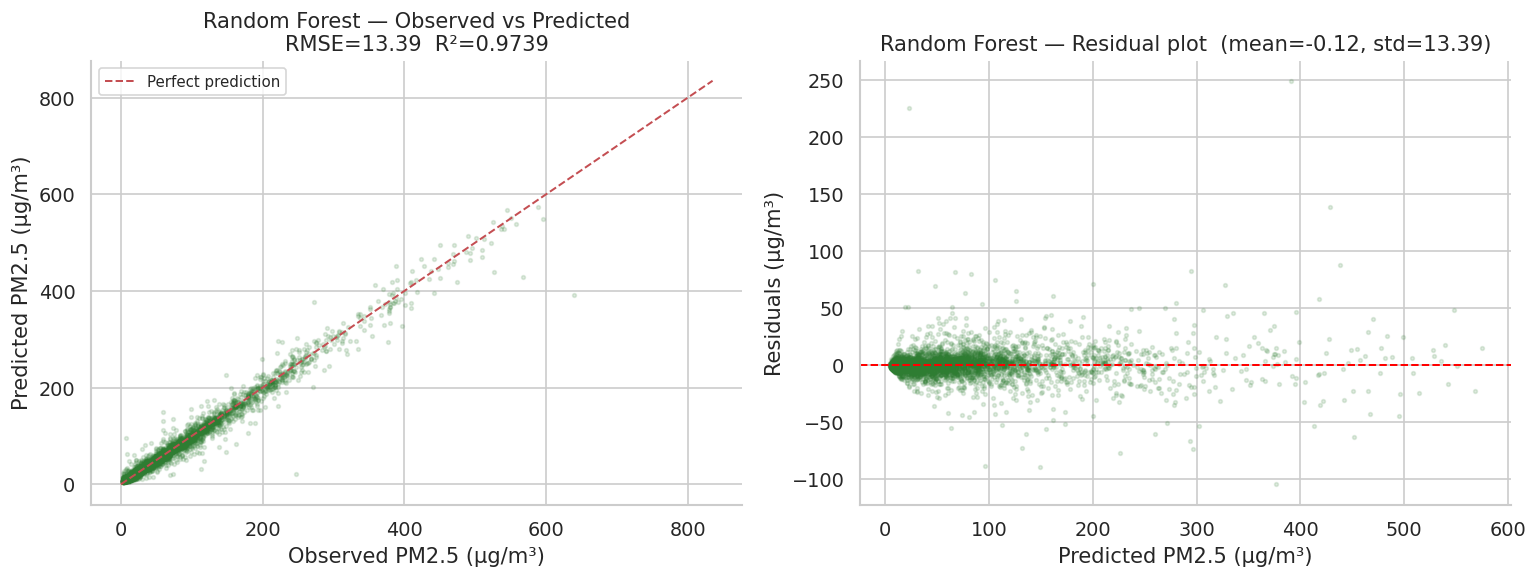

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test[idx], rf_test_pred[idx], alpha=0.15, s=5, color=COLOR_RF)
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
ax.set_xlabel('Observed PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Random Forest — Observed vs Predicted\nRMSE={metrics_rf_te["RMSE"]:.2f}  R²={metrics_rf_te["R2"]:.4f}')
ax.legend(fontsize=9)

ax = axes[1]
res_rf = y_test - rf_test_pred
ax.scatter(rf_test_pred[idx], res_rf[idx], alpha=0.15, s=5, color=COLOR_RF)
ax.axhline(0, color='red', lw=1.2, ls='--')
ax.set_xlabel('Predicted PM2.5 (µg/m³)')
ax.set_ylabel('Residuals (µg/m³)')
ax.set_title(f'Random Forest — Residual plot  (mean={res_rf.mean():.2f}, std={res_rf.std():.2f})')

plt.tight_layout()
plt.savefig('fig_rf_diagnostics.png', bbox_inches='tight')
plt.show()

---
<a name="gradient"></a>

## 7. Model 3 — Gradient Boosting

**Course reference — Module 6, Gradient Boosting:**
- Builds T weak learners **sequentially**: each one fits the pseudo-residuals of the previous
- Regularised by **learning rate ν** (*"If ν = 1 then there is no regularization"*)
- Prone to overfitting → ν and T must be tuned

**Implementation**: `HistGradientBoostingRegressor` (sklearn) — histogram-based implementation, identical concept to the course, optimised for large datasets (420k rows). `learning_rate` = ν, `max_iter` = T.

In [15]:
# ── Gradient Boosting — reduced grid for Colab ───────────────────────────────
# 8 combinations × 5 folds = 40 fits (was 27 × 5 = 135 fits)
# HistGradientBoostingRegressor is already fast (histogram-based)
# but the full grid is too slow on 420k rows in Colab.
#
# learning_rate = ν (regularization — course Module 6 slide 21)
# max_iter      = T (number of boosting rounds)
# max_depth     = depth of each weak learner

gb_grid = {
    'learning_rate': [0.05, 0.1],    # was [0.05, 0.1, 0.2]
    'max_iter'     : [200, 300],     # was [100, 200, 300] — low values rarely win
    'max_depth'    : [5],            # 5 is the sweet spot for GB on tabular data
}

gb_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_grid,
    cv=TSCV,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gb_search.fit(X_train, y_train)

print(f'\nBest hyperparameters : {gb_search.best_params_}')
print(f'Best CV RMSE         : {-gb_search.best_score_:.3f}')
gb = gb_search.best_estimator_

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best hyperparameters : {'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 200}
Best CV RMSE         : 15.328


In [16]:
gb_train_pred = gb.predict(X_train)
gb_test_pred  = gb.predict(X_test)

metrics_gb_tr = compute_metrics(y_train, gb_train_pred, 'Gradient Boosting — apparent (train)')
metrics_gb_te = compute_metrics(y_test,  gb_test_pred,  'Gradient Boosting — test')

gap = metrics_gb_tr['RMSE'] - metrics_gb_te['RMSE']
print(f'\nOverfitting check — RMSE gap (train − test): {gap:.3f}')
print('→ ' + ('Possible overfitting' if abs(gap) > 5 else 'No sign of overfitting'))

RESULTS['Gradient Boosting'] = metrics_gb_te

Gradient Boosting — apparent (train)  RMSE= 13.158   MAE=  7.561   R²=0.9731
Gradient Boosting — test             RMSE= 12.572   MAE=  6.893   R²=0.9770

Overfitting check — RMSE gap (train − test): 0.586
→ No sign of overfitting


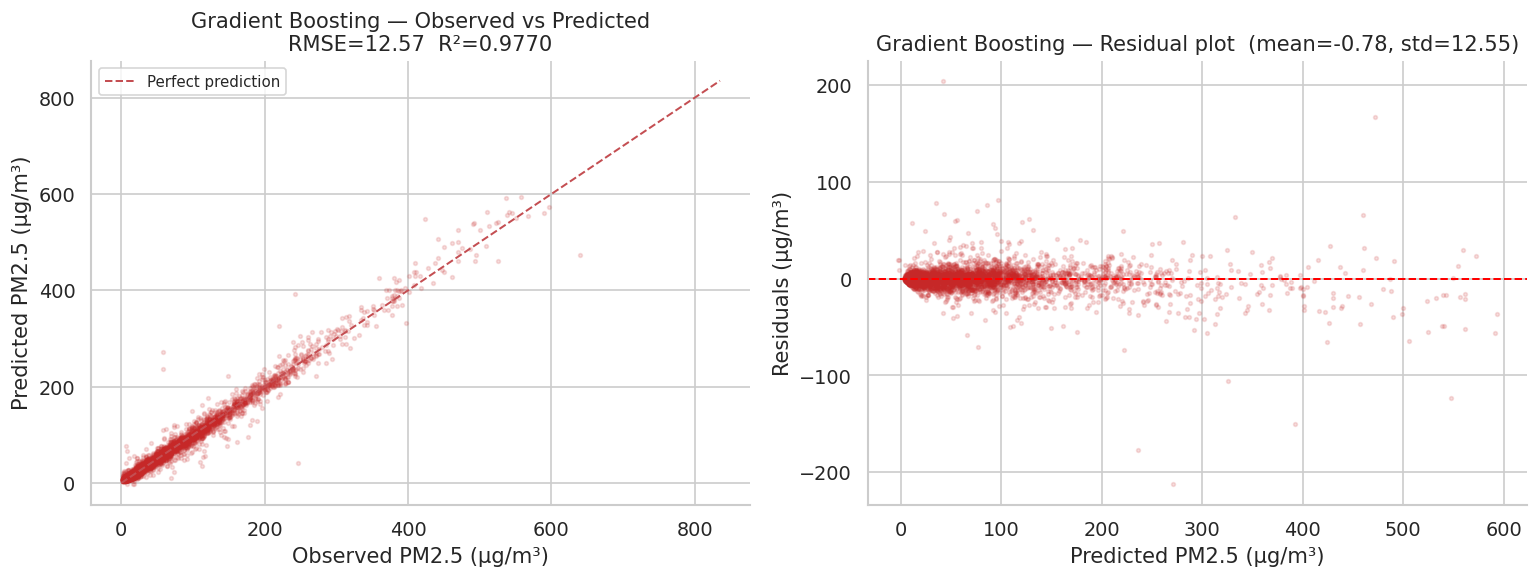

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test[idx], gb_test_pred[idx], alpha=0.15, s=5, color=COLOR_GB)
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
ax.set_xlabel('Observed PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Gradient Boosting — Observed vs Predicted\nRMSE={metrics_gb_te["RMSE"]:.2f}  R²={metrics_gb_te["R2"]:.4f}')
ax.legend(fontsize=9)

ax = axes[1]
res_gb = y_test - gb_test_pred
ax.scatter(gb_test_pred[idx], res_gb[idx], alpha=0.15, s=5, color=COLOR_GB)
ax.axhline(0, color='red', lw=1.2, ls='--')
ax.set_xlabel('Predicted PM2.5 (µg/m³)')
ax.set_ylabel('Residuals (µg/m³)')
ax.set_title(f'Gradient Boosting — Residual plot  (mean={res_gb.mean():.2f}, std={res_gb.std():.2f})')

plt.tight_layout()
plt.savefig('fig_gb_diagnostics.png', bbox_inches='tight')
plt.show()

---
<a name="comparison"></a>

## 8. Model Comparison

In [18]:
results_df = pd.DataFrame(RESULTS).T.round(4)
results_df.index.name = 'Model'

non_base = results_df.loc[results_df.index != 'Baseline']
best_rmse = non_base['RMSE'].idxmin()
best_mae  = non_base['MAE'].idxmin()
best_r2   = non_base['R2'].idxmax()

print('=== Model comparison — Test set metrics ===')
display(results_df)
print(f'Best RMSE : {best_rmse}')
print(f'Best MAE  : {best_mae}')
print(f'Best R²   : {best_r2}')

improvement = (1 - results_df.loc[best_rmse, 'RMSE'] / results_df.loc['Baseline', 'RMSE']) * 100
print(f'\nRMSE improvement of best model vs baseline: {improvement:.1f}%')

=== Model comparison — Test set metrics ===


,RMSE,MAE,R2
Model,,,
Baseline,82.9584,59.5572,-0.0007
Ridge,15.1352,8.7751,0.9667
Random Forest,13.3909,7.1387,0.9739
Gradient Boosting,12.5725,6.8930,0.9770


Best RMSE : Gradient Boosting
Best MAE  : Gradient Boosting
Best R²   : Gradient Boosting

RMSE improvement of best model vs baseline: 84.8%


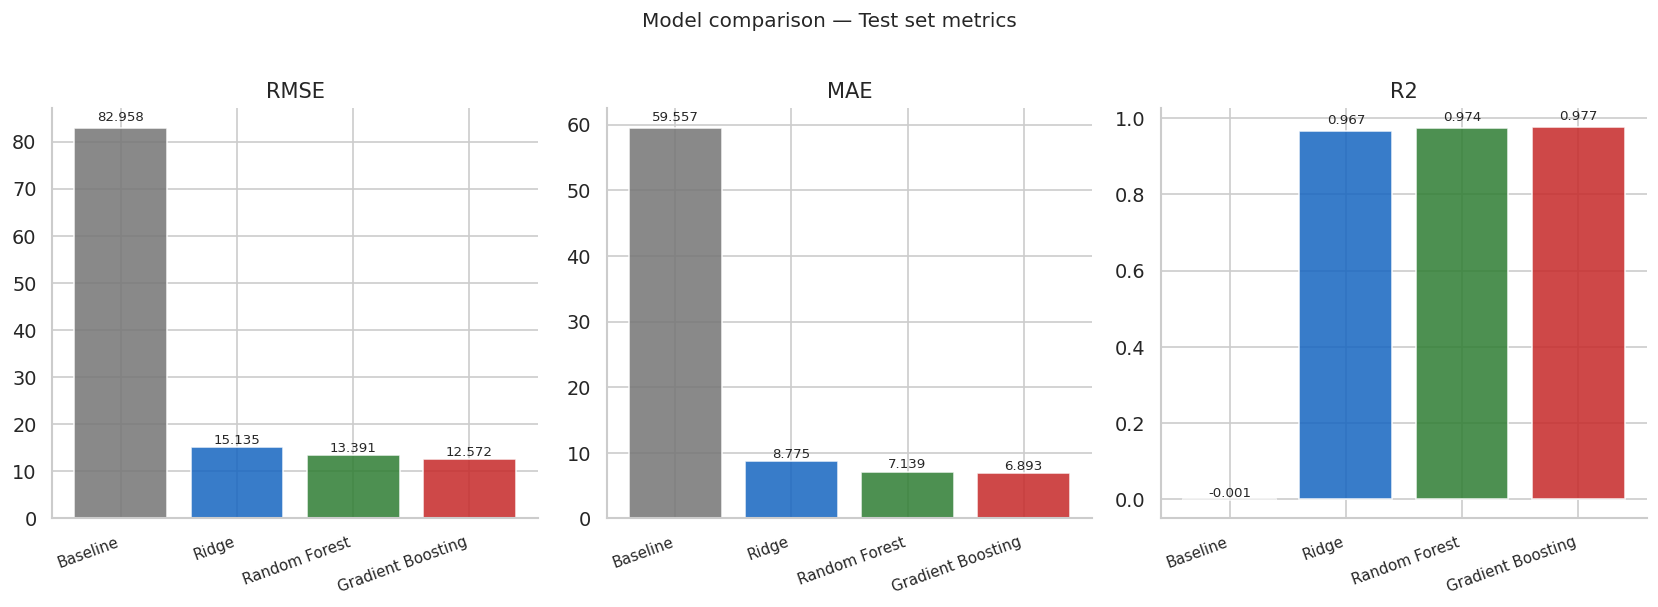

In [19]:
models  = list(RESULTS.keys())
colors  = [COLOR_BASE, COLOR_RIDGE, COLOR_RF, COLOR_GB]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    vals = [RESULTS[m][metric] for m in models]
    bars = ax.bar(models, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model comparison — Test set metrics', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()

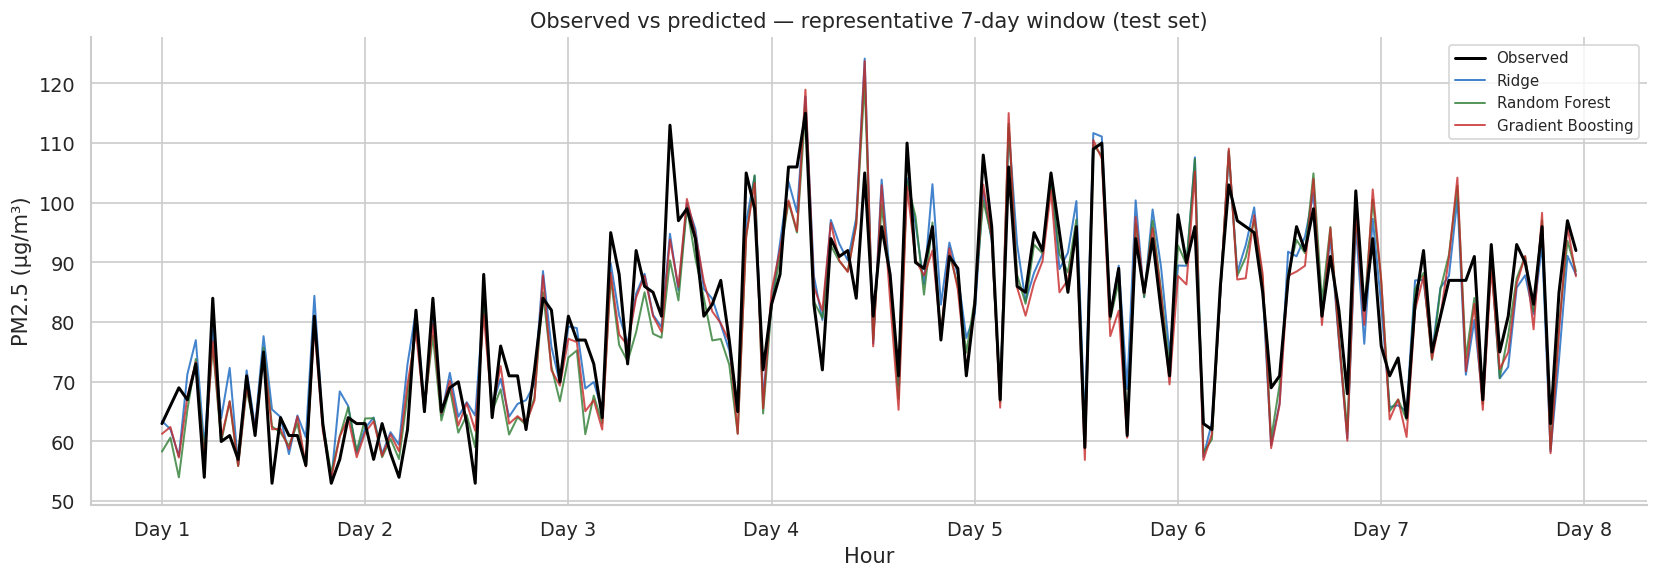

In [20]:
# 7-day window of predictions vs observations (test set)
mid   = len(y_test) // 2
start, end = mid - 84, mid + 84
hours = np.arange(168)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hours, y_test[start:end],          color='black',     lw=1.8, label='Observed',          zorder=5)
ax.plot(hours, ridge_test_pred[start:end], color=COLOR_RIDGE, lw=1.2, label='Ridge',    alpha=0.8)
ax.plot(hours, rf_test_pred[start:end],    color=COLOR_RF,    lw=1.2, label='Random Forest', alpha=0.8)
ax.plot(hours, gb_test_pred[start:end],    color=COLOR_GB,    lw=1.2, label='Gradient Boosting', alpha=0.8)
ax.set_xlabel('Hour')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Observed vs predicted — representative 7-day window (test set)')
ax.legend(fontsize=9)
ax.set_xticks(range(0, 169, 24))
ax.set_xticklabels([f'Day {i+1}' for i in range(8)])
plt.tight_layout()
plt.savefig('fig_timeseries_predictions.png', bbox_inches='tight')
plt.show()

---
<a name="feature"></a>

## 9. Feature Importance

**Course reference — Module 3.2**: *"The most important feature is at the top of the graph."*

- **Ridge**: absolute coefficient magnitudes (features are scaled → comparable)
- **Random Forest**: built-in impurity-based importance
- **Gradient Boosting**: built-in importance (or permutation importance as fallback)

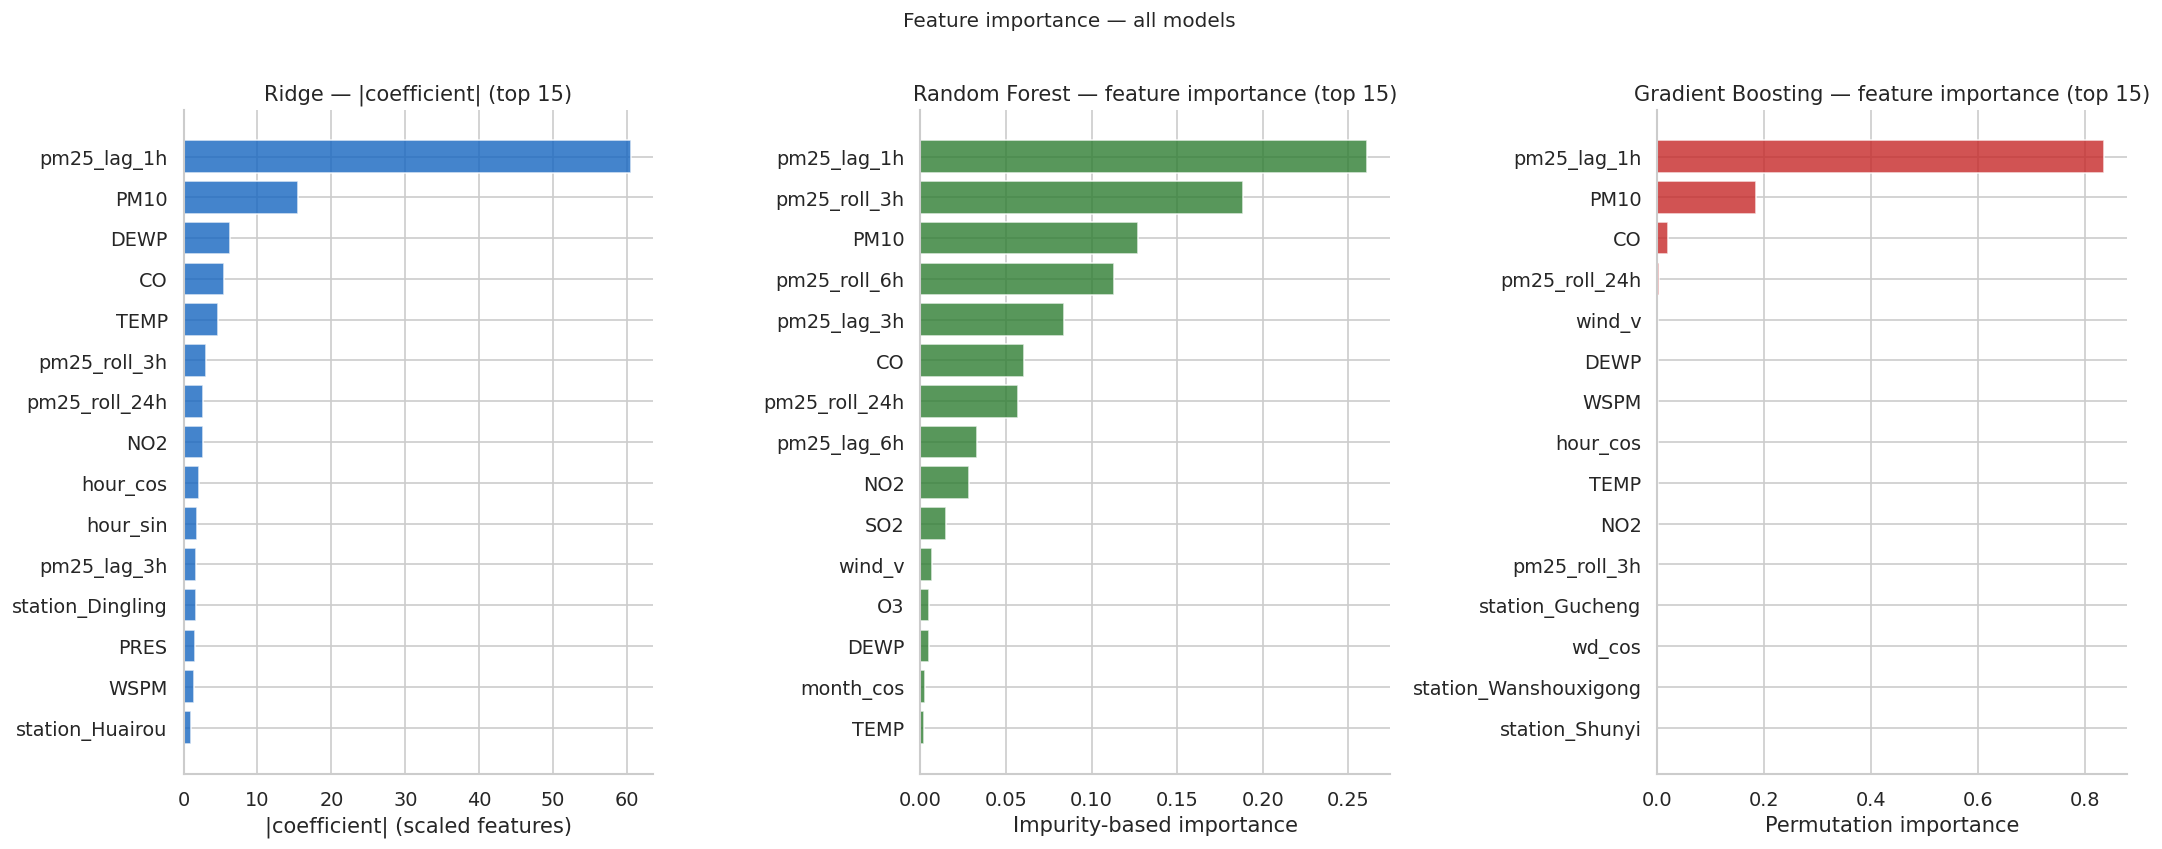

In [21]:
TOP_N = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Ridge
ax = axes[0]
ridge_coef = pd.Series(np.abs(ridge.coef_), index=FEATURES).sort_values(ascending=False).head(TOP_N)
ax.barh(ridge_coef.index[::-1], ridge_coef.values[::-1], color=COLOR_RIDGE, alpha=0.8)
ax.set_title(f'Ridge — |coefficient| (top {TOP_N})')
ax.set_xlabel('|coefficient| (scaled features)')

# Random Forest
ax = axes[1]
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(TOP_N)
ax.barh(rf_imp.index[::-1], rf_imp.values[::-1], color=COLOR_RF, alpha=0.8)
ax.set_title(f'Random Forest — feature importance (top {TOP_N})')
ax.set_xlabel('Impurity-based importance')

# Gradient Boosting
ax = axes[2]
if hasattr(gb, 'feature_importances_'):
    gb_imp = pd.Series(gb.feature_importances_, index=FEATURES).sort_values(ascending=False).head(TOP_N)
    xlabel = 'Impurity-based importance'
else:
    perm   = permutation_importance(gb, X_test[:5000], y_test[:5000],
                                    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
    gb_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False).head(TOP_N)
    xlabel = 'Permutation importance'
ax.barh(gb_imp.index[::-1], gb_imp.values[::-1], color=COLOR_GB, alpha=0.8)
ax.set_title(f'Gradient Boosting — feature importance (top {TOP_N})')
ax.set_xlabel(xlabel)

plt.suptitle('Feature importance — all models', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

In [22]:
top10_ridge = set(ridge_coef.head(10).index)
top10_rf    = set(rf_imp.head(10).index)
top10_gb    = set(gb_imp.head(10).index)

consensus_3 = top10_ridge & top10_rf & top10_gb
consensus_2 = (top10_ridge & top10_rf) | (top10_ridge & top10_gb) | (top10_rf & top10_gb)

print(f'Features in top 10 across ALL 3 models ({len(consensus_3)}):')
for f in sorted(consensus_3):
    print(f'  {f}')

print(f'\nFeatures in top 10 across at least 2 models ({len(consensus_2)}):')
for f in sorted(consensus_2):
    print(f'  {f}')

Features in top 10 across ALL 3 models (5):
  CO
  NO2
  PM10
  pm25_lag_1h
  pm25_roll_24h

Features in top 10 across at least 2 models (9):
  CO
  DEWP
  NO2
  PM10
  TEMP
  hour_cos
  pm25_lag_1h
  pm25_roll_24h
  pm25_roll_3h


---
<a name="summary"></a>

## 10. Summary & Implications for Notebook 4

In [23]:
print('=== FINAL RESULTS — Test set ===')
display(results_df)
best = non_base['RMSE'].idxmin()
impr = (1 - results_df.loc[best, 'RMSE'] / results_df.loc['Baseline', 'RMSE']) * 100
print(f'\nBest model : {best}  ({impr:.1f}% RMSE improvement over baseline)')

=== FINAL RESULTS — Test set ===


,RMSE,MAE,R2
Model,,,
Baseline,82.9584,59.5572,-0.0007
Ridge,15.1352,8.7751,0.9667
Random Forest,13.3909,7.1387,0.9739
Gradient Boosting,12.5725,6.8930,0.9770



Best model : Gradient Boosting  (84.8% RMSE improvement over baseline)


### Supervised Learning Summary — Key Findings

#### Validation strategy

- `TimeSeriesSplit(n_splits=5)` preserves temporal causal order.
- A random split would create data leakage because PM2.5 has strong temporal autocorrelation, especially at lag 1h.
- An 80/20 temporal train/test split was used.
- The test set was never used during training or hyperparameter tuning.

#### Overfitting check

- Apparent train metrics and test metrics were reported for every model.
- A large difference between train and test performance would indicate possible overfitting.
- In this notebook, the train/test RMSE gaps remain small, suggesting no major overfitting.

#### Model performance

- All three supervised models substantially outperform the baseline.
- Ridge Regression is linear, fast, and interpretable, making it a useful lower-bound model.
- Random Forest handles non-linear relationships and interactions well.
- Gradient Boosting achieves the best overall performance and provides the lowest RMSE.

#### Key predictors

- Lag features are among the strongest predictors, especially `pm25_lag_1h`.
- Rolling mean features such as `pm25_roll_3h` and `pm25_roll_24h` capture recent pollution trends.
- Co-pollutants such as `PM10`, `CO`, and `NO2` are also important predictors.
- Station information is included, but predictive performance is mainly driven by temporal lag features and co-pollutants.

#### Implications for Notebook 4 — Unsupervised Learning

- Since station information captures spatial differences, spatial clustering remains meaningful.
- K-Means can be applied to mean pollutant profiles per station.
- PCA can be used on pollutants and weather variables to visualise latent structure.